<a href="https://colab.research.google.com/github/opherdonchin/BayesShortCourse/blob/main/sleep/01_linear_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sleep deprivation 1 — Linear baseline

Start with one population-average linear relationship. Because `Days = 0` is the pre-deprivation baseline, the intercept has a direct scientific interpretation and we put its prior on that scale.

## Setup

This course pins PyMC, modular ArviZ, and Bambi for reproducibility because their APIs can change across major versions.

In [9]:
%pip install -q \
    "pymc==6.3.2" \
    "arviz-base==1.3.0" \
    "arviz-stats==1.3.2" \
    "arviz-plots[matplotlib]==1.3.1" \
    "bambi==0.21.0"

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import bambi as bmb
import pymc as pm
import arviz_base as azb
import arviz_stats as azs
import arviz_plots as azp

RANDOM_SEED = 20260924
azp.style.use("arviz-variat")

print("PyMC:", pm.__version__)
print("Bambi:", bmb.__version__)
print("arviz-base:", azb.__version__)
print("arviz-plots:", azp.__version__)
print("arviz-stats:", azs.__version__)

PyMC: 6.3.2
Bambi: 0.21.0
arviz-base: 1.3.0
arviz-plots: 1.3.1
arviz-stats: 1.3.2


## Data

The original study contains two adaptation/training days followed by a baseline measurement and then seven nights of severe sleep restriction. Following the chapter, we drop original days 0–1 and subtract 2 from the remaining day number. Therefore **`Days = 0` is the baseline measurement before sleep deprivation begins**.

That zero point is scientifically meaningful, so every Bambi model in this sequence uses `center_predictors=False`. The `Intercept` prior is therefore a prior on baseline reaction time rather than reaction time at the average deprivation day.

In [11]:
DATA_URL = "https://raw.githubusercontent.com/vincentarelbundock/Rdatasets/master/csv/lme4/sleepstudy.csv"

sleep = pd.read_csv(DATA_URL).drop(columns="rownames")
sleep = sleep.loc[sleep["Days"] >= 2].copy()
sleep["Days"] = sleep["Days"] - 2
sleep["Subject"] = sleep["Subject"].astype(str)
sleep = sleep.reset_index(drop=True)

print(f"{sleep['Subject'].nunique()} participants, {len(sleep)} observations")
print(f"Days: {sleep['Days'].min()} to {sleep['Days'].max()}")
sleep.head()

18 participants, 144 observations
Days: 0 to 7


,Reaction,Days,Subject
0,250.8006,0,308
1,321.4398,1,308
2,356.8519,2,308
3,414.6901,3,308
4,382.2038,4,308


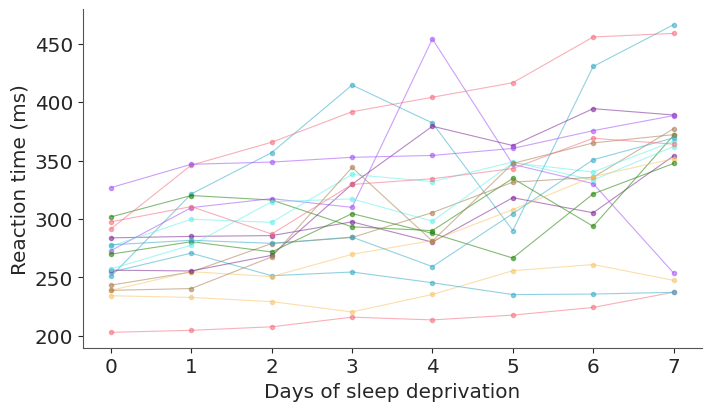

In [12]:
fig, ax = plt.subplots(figsize=(7, 4))
for subject, group in sleep.groupby("Subject"):
    ax.plot(group["Days"], group["Reaction"], marker="o", ms=3, lw=0.8, alpha=0.55)
ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)")
plt.show()

# 1.1 Prior implications

What reaction times and daily sleep-deprivation effects are plausible before seeing the data?

The model is

$$\text{Reaction}_i \sim \mathcal{N}(\alpha + \beta \cdot \text{Days}_i,\ \sigma)$$

We set the priors from the literature, not from this dataset:

- **Intercept $\alpha$ (baseline RT, `Days = 0`) $\sim \mathcal{N}(250, 30)$ ms.** Well-rested adults average about 250 ms on the psychomotor vigilance test (PVT), and most fall between 200 and 300 ms ([Basner & Dinges 2011](https://pubmed.ncbi.nlm.nih.gov/21532951/); [Basner et al. 2020](https://pmc.ncbi.nlm.nih.gov/articles/PMC8240655/)).
- **Slope $\beta$ (change per day of restriction) $\sim \mathcal{N}(10, 10)$ ms/day.** Belenky et al. (2003), the source of this dataset, found that PVT speed declined steadily over 7 nights of 3 h time in bed ([Belenky et al. 2003](https://onlinelibrary.wiley.com/doi/abs/10.1046/j.1365-2869.2003.00337.x)). So we expect slowing, but we leave room for no effect ($\beta \approx 0$) and for large effects (~30 ms/day, i.e. +200 ms after a week).
- **Residual SD $\sigma \sim \text{HalfNormal}(50)$ ms.** This covers both between-person and day-to-day variation, which this model cannot yet tell apart.

We check these priors by simulating the reaction times they imply.

In [ ]:
priors = {
    "Intercept": bmb.Prior("Normal", mu=250, sigma=30),
    "Days": bmb.Prior("Normal", mu=10, sigma=10),
    "sigma": bmb.Prior("HalfNormal", sigma=50),
}
model = bmb.Model("Reaction ~ Days", sleep, priors=priors, center_predictors=False)
model.build()

with model.backend.model:
    prior = pm.sample_prior_predictive(draws=500, random_seed=RANDOM_SEED)
model

In [ ]:
alpha = prior["prior"]["Intercept"].values.ravel()
beta = prior["prior"]["Days"].values.ravel()
y_prior = prior["prior_predictive"]["Reaction"].values.reshape(-1, len(sleep))

days = np.arange(8)
fig, ax = plt.subplots(figsize=(7, 4))
# 90% prior predictive interval for a single observation on each day
band = np.array([np.percentile(y_prior[:, sleep["Days"] == d], [5, 95]) for d in days])
ax.fill_between(days, band[:, 0], band[:, 1], color="C0", alpha=0.2, label="90% prior predictive")
# 100 prior draws of the population-average line
for a, b in zip(alpha[:100], beta[:100]):
    ax.plot(days, a + b * days, color="C0", lw=0.5, alpha=0.3)
ax.plot([], [], color="C0", lw=0.8, label="prior mean lines")
ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)", ylim=(0, 700))
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.show()

print(f"P(slope < 0)              = {(beta < 0).mean():.2f}")
print(f"P(mean RT at day 7 > 500) = {(alpha + 7 * beta > 500).mean():.2f}")
print(f"P(predicted RT < 100 ms)  = {(y_prior < 100).mean():.3f}")

# 1.2 Population effect

What population-average change in reaction time does the data support?

We fit the model and check the sampler before reading any numbers. Then we summarize three population-level quantities:

- **Baseline mean** $\alpha$: average RT before deprivation (`Days = 0`).
- **Daily increase** $\beta$: average extra ms of RT per day of restriction.
- **Total increase** $7\beta$: average extra ms after all 7 days (day 7 vs. day 0).

These describe uncertainty about the *average* line. They are not predictions for an individual person (that is 1.3).

**Before interpreting:** there should be no divergences, $\hat R \le 1.01$ and bulk/tail ESS in the hundreds or more.

In [ ]:
idata = model.fit(draws=1000, chains=4, random_seed=RANDOM_SEED)

print("Divergences:", int(idata["sample_stats"]["diverging"].sum()))
azs.summary(idata, var_names=["Intercept", "Days", "sigma"], ci_prob=0.9)

In [ ]:
post = idata["posterior"]
post["baseline_mean"] = post["Intercept"]
post["daily_increase"] = post["Days"]
post["total_increase_7d"] = 7 * post["Days"]
post["day7_mean"] = post["Intercept"] + 7 * post["Days"]

azs.summary(
    idata,
    var_names=["baseline_mean", "daily_increase", "total_increase_7d", "day7_mean"],
    kind="stats",
    ci_prob=0.9,
)

In [ ]:
alpha_post = post["Intercept"].values.ravel()
beta_post = post["Days"].values.ravel()
mu = alpha_post[:, None] + beta_post[:, None] * days  # posterior of the average line

fig, ax = plt.subplots(figsize=(7, 4))
ax.scatter(sleep["Days"], sleep["Reaction"], s=10, color="0.5", alpha=0.6, label="observed")
ax.fill_between(days, *np.percentile(mu, [5, 95], axis=0), color="C1", alpha=0.3, label="90% interval, average RT")
ax.plot(days, mu.mean(axis=0), color="C1", lw=2, label="posterior mean")
ax.set(xlabel="Days of sleep deprivation", ylabel="Reaction time (ms)")
ax.legend(frameon=False, fontsize=9, loc="upper left")
plt.show()

**Reading the answer** (from the summary table above, posterior mean and 90% HDI):

- *What is the mean?* `baseline_mean` is the average rested RT. Compare it with the ~250 ms from the literature.
- *Mean increase per day?* `daily_increase`. If its 90% HDI is well above 0, the data support steady slowing.
- *Total increase over all days?* `total_increase_7d` is the average slowing from day 0 to day 7, and `day7_mean` is the average RT at day 7.

The band in the plot is uncertainty about the **average** line. It is narrow even though individual participants scatter widely around it. That spread is what 1.3 and 1.5 look at.

# 1.3 Predictive adequacy

Can a single population-average line reproduce the observed reaction-time distribution?

# 1.4 Prior sensitivity

How sensitive are the main posterior conclusions to modest changes in the priors?

# 1.5 Missing structure

What important structure in the data does this population-average model fail to represent?